In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

F_Byrne, N_0 = 8.922473368689328, 1539351
D = int(N_0*(F_Byrne-1))
D

12195467

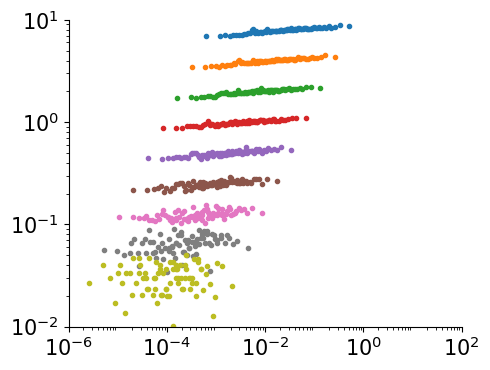

In [2]:
def plot(df_bins):
    x = df_bins['mean_count']
    y = (df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count'] -1
    plt.scatter(x,y,marker='.')
    F.append(y.mean())
    F_err.append(y.std())
    

plt.figure(figsize=(5,3.8), facecolor='white')

ax = plt.subplot(1,1,1)

F = []
F_err = []

df_bins = pd.read_csv('../binning_real_data_q/df_bins_Byrne_IM_80bins.csv',index_col=0)
plot(df_bins)

for t in [2,4,8,16,32,64,128,256]:
    df_bins = pd.read_csv('../binning_real_data_q/df_bins_Byrne_IM_%dt.csv'%t,index_col=0)
    plot(df_bins)

plt.xlim(1e-6,1e2)
plt.ylim(1e-2,1e1)
plt.xscale('log')
plt.yscale('log')
plt.xticks([1e-6,1e-4,1e-2,1e0,1e2],fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('Byrne_different_depth.png', dpi=1200)

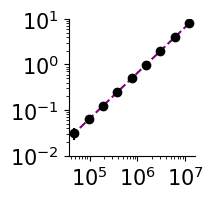

In [3]:
plt.figure(figsize=(2.2,2.1))
ax = plt.subplot(111)

plt.errorbar(D/(2**np.arange(9)), F, yerr=F_err, color='black', linestyle='', marker='o')
plt.plot(D/(2**np.arange(9)), D/(2**np.arange(9))/N_0, color='purple', linestyle='--')
plt.ylim(1e-2,1e1)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('Byrne_noise_vs_depth.png',dpi=1200)

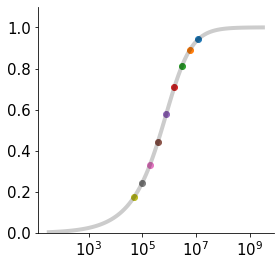

In [6]:
plt.figure(figsize=(4,3.8), facecolor='white')
ax = plt.subplot(111)

pseq = np.loadtxt('../binning_real_data_q/Byrne_TSKATIA_p_seq_different_t.csv')
snr_vec = np.sqrt(pseq/(2**np.arange(9)) * D / (np.array(F)+1))

def snr(x):
    return np.sqrt(pseq[0]*x/(1+x/N_0))

for i in range(9):
    plt.scatter(D/(2**i), snr_vec[i]/snr(10**11))



x=10**np.linspace(1.5,9.5,100)
plt.plot(x,snr(x)/snr(10**11),linewidth=4,color='black', alpha=0.2)

plt.xscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0,1.1)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('snr_vs_D.png', dpi=1200)

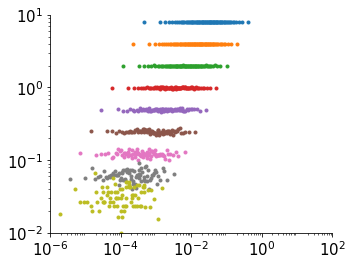

In [52]:
def plot(df_bins):
    x = df_bins['mean_count']
    y = (df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count'] -1
    plt.scatter(x,y,marker='.')
    F.append(y.mean())
    F_err.append(y.std())
    

plt.figure(figsize=(5,3.8), facecolor='white')

ax = plt.subplot(1,1,1)

F = []
F_err = []

df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_25amp_rounds.csv',index_col=0)
plot(df_bins)

for t in [2,4,8,16,32,64,128,256]:
    df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_%dt.csv'%t,index_col=0)
    plot(df_bins)

plt.xlim(1e-6,1e2)
plt.ylim(1e-2,1e1)
plt.xscale('log')
plt.yscale('log')
plt.xticks([1e-6,1e-4,1e-2,1e0,1e2],fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('simulation_Byrne_different_depth.png', dpi=1200)

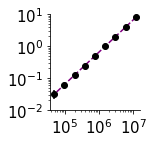

In [55]:
plt.figure(figsize=(2.2,2.1))
ax = plt.subplot(111)

plt.errorbar(D/(2**np.arange(9)), F, yerr=F_err, color='black', linestyle='', marker='o')
plt.plot(D/(2**np.arange(9)), D/(2**np.arange(9))/N_0, color='purple', linestyle='--')
plt.ylim(1e-2,1e1)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('simulation_Byrne_noise_vs_depth.png',dpi=1200)

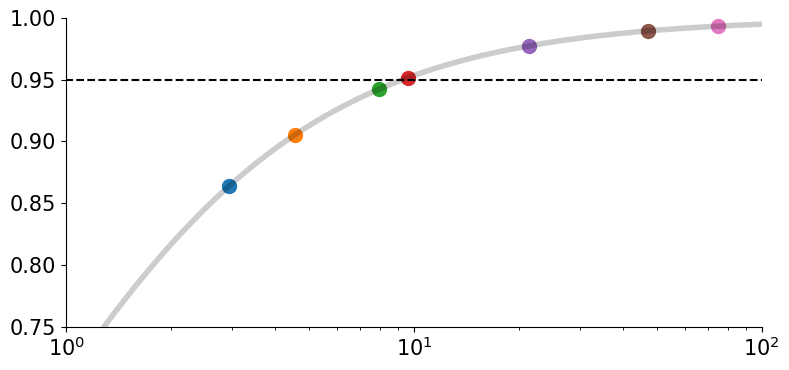

In [9]:
df = pd.read_csv('../scRNAseq_data/df.csv',index_col=0).iloc[[0,1,2,3,5,6,8]]

plt.figure(figsize=(8,3.8),facecolor='white')
x = np.logspace(-2,2, 150)
y = np.sqrt(x/(1+x))

ax = plt.subplot(111)
plt.plot(x,y,linewidth=4, color='black', alpha=0.2)
    
for i in range(len(df)): 
    ax = plt.subplot(111)
    plt.scatter([df.iloc[i]['R']/df.iloc[i]['N_0']], [df.iloc[i]['sat_frac']], s=100, label=df.iloc[i].name)
    
plt.hlines(0.95,1e-7,1e7,linestyle='--', color='black')
plt.xscale('log')
plt.xlim(1,1e2)
plt.ylim(0.75,1.0)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('saturation_fraction_vs_ratio.png',dpi=1200)

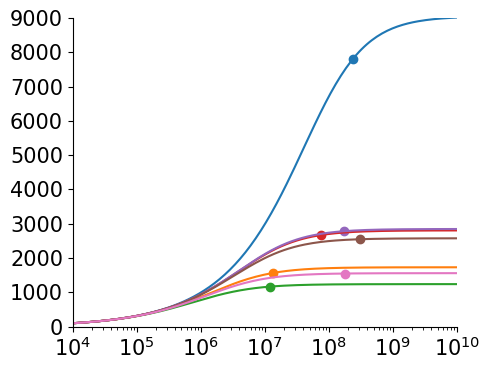

In [27]:
df = pd.read_csv('../scRNAseq_data/df.csv',index_col=0).iloc[[0,1,2,3,5,6,8]]

plt.figure(figsize=(5,3.8),facecolor='white')
ax = plt.subplot(111)

x = np.logspace(4,10,150)

for i in range(len(df)):
    N = df['N_0'].iloc[i]
    D = df['R'].iloc[i]
    plt.plot(x, np.sqrt(x*N/(x+N)))
    plt.scatter([D],[np.sqrt(D*N/(D+N))])
    

    
        
plt.xscale('log')
#plt.yscale('log')
plt.xlim(1e4,1e10)
plt.ylim(0,9000)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('relative_snr_vs_D.png',dpi=1200)

In [28]:
df

,mean,variance,F,R,N_0,sat_frac,uniques
TwistT0,NaN,NaN,3.936907,240537294.0,8.190157e+07,0.863709,98468090.0
DalkaraT0,NaN,NaN,5.550332,13653491.0,3.000548e+06,0.905445,1252032.0
ByrneT0,NaN,NaN,8.922473,12195473.0,1.539352e+06,0.942297,3071451.0
HBreastCancer,0.017653,0.187518,10.622273,75820168.0,7.879653e+06,0.951766,14512602.0
MBrain,0.040356,0.902225,22.356840,173326275.0,8.115727e+06,0.977380,16020053.0
MBrainCoronal,0.072693,3.490021,48.010542,312213184.0,6.641344e+06,0.989531,16429852.0
HPBMC2,0.042452,3.221978,75.896609,182330818.0,2.434434e+06,0.993390,14974774.0
